<a href="https://colab.research.google.com/github/ruforavishnu/Project_Simulations/blob/main/12thStandardMaths_Chapter5_Continuity_and_Differentiability.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Checking continutiy and differentiability

In [1]:
import sympy as sp


Lets try to solve this problem first

For \(f(x)\):

$$
f(x) =
\begin{cases}
x^2, &x < 0 \\
x+1, &x \geq 0
\end{cases}
$$


For \(g(x)\):

$$
g(x) = |x|
$$



In [2]:
x = sp.symbols('x')

f = sp.Piecewise((x**2, x < 0),   (x+1, x >= 0))

In [8]:
left_limit = sp.limit(f, x, 0, dir='-')

right_limit = sp.limit(f, x, 0, dir='+')

value_at_0 = f.subs(x, 0)



print('Left limit at x=0: ', left_limit)
print('Right limit at x=0: ', right_limit)
print('Function value at x=0: ', value_at_0)


if left_limit == right_limit == value_at_0:
  print('\nFunction is continuous at x=0')
else:
  print('Function is not continuous at x=0')




Left limit at x=0:  1
Right limit at x=0:  1
Function value at x=0:  1

Function is continuous at x=0


Now lets check differentiability

In [9]:
f_diff = sp.diff(f, x)



In [10]:
#left hand derivative and right hand derivative
LHD = sp.limit(f_diff, x , 0 , dir='-')
RHD = sp.limit(f_diff, x, 0, dir='+')

print('Left derivative at x = 0: ', LHD)
print('Right derivative at x = 0: ', RHD)

Left derivative at x = 0:  1
Right derivative at x = 0:  1


In [11]:
if LHD == RHD:
  print('Function is differentiable at x=0')
else:
  print('Function is not differentiable at x=0')

Function is differentiable at x=0


ok, so now that we have that . lets  plot it

In [14]:
import numpy as np
import matplotlib.pyplot as plt

In [17]:
f_lambda = sp.lambdify(x, f, 'numpy')

X = np.linspace(-3, 3, 400)
Y = f_lambda(X)



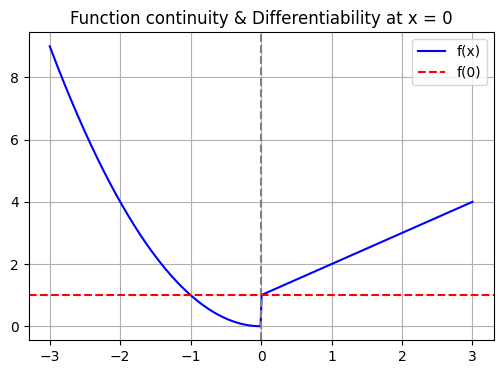

In [20]:
plt.figure(figsize=(6,4))
plt.plot(X, Y, label='f(x)', color='blue')

plt.axvline(0, color='gray', linestyle='--')
plt.axhline(float(value_at_0), color='red', linestyle='--', label='f(0)')

plt.title('Function continuity & Differentiability at x = 0')
plt.legend()
plt.grid(True)
plt.show()

## lets try solving another problem

For \(f(x)\):


Find the values of a and b such that

\\

$$
\begin{cases}
acos(x) + bsin(x) , &x < 0 \\
x^2 + 1 , &x \geq 0
\end{cases}
$$


\\


is continuous and differentiable at x=0

In [24]:
import sympy as sp
import numpy as np

import matplotlib.pyplot as plt




In [25]:
x, a, b = sp.symbols('x a b ', real=True)



In [27]:
f1 = a *  sp.cos(x)  + b * sp.sin(x)
f2 = x**2 + 1

LHL = sp.limit(f1, x, 0, dir='-')
RHL = sp.limit(f2, x, 0,dir='+')

f0 = f2.subs(x, 0)

continuity_eq = sp.Eq(LHL, f0)



now lets differentiate it

In [28]:
f1_diff = sp.diff(f1, x)

f2_diff = sp.diff(f2, x)




In [29]:
LHD = sp.limit(f1_diff, x, 0 , dir='-')
RHD = sp.limit(f2_diff, x, 0, dir='+')

differentiability_eq = sp.Eq(LHD, RHD)



now lets solve it

In [30]:
solution = sp.solve([continuity_eq, differentiability_eq],  (a,b))
solution

{a: 1, b: 0}

### fine , now so thats sorted. lets think of plotting it

In [33]:
a_val, b_val = solution[a], solution[b]

f1_num  = sp.lambdify(x, f1.subs({a:a_val, b:b_val}) , 'numpy' )
f2_num  = sp.lambdify(x, f2, 'numpy')


X1 = np.linspace(-5 , 0, 200)
X2 = np.linspace(0, 5, 200)

Y1 = f1_num(X1)
Y2= f2_num(X2)

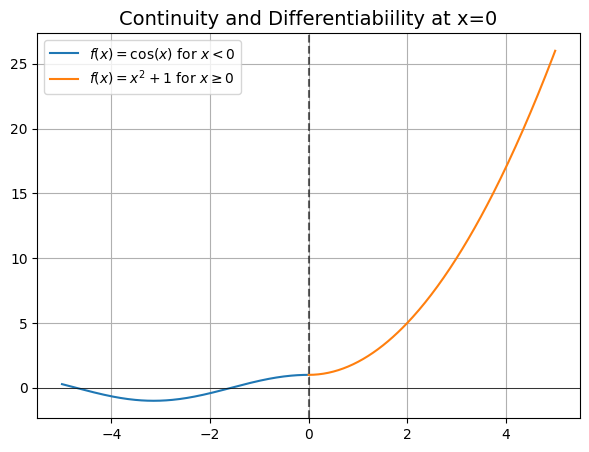

In [34]:
plt.figure(figsize=(7,5))
plt.plot(X1, Y1, label=r"$f(x) = \cos(x)$ for $x<0$")
plt.plot(X2, Y2, label=r"$f(x)=x^2+1$ for $x\geq0$")
plt.axvline(0, color='k', linestyle='--', alpha=0.6)
plt.axhline(0, color='k', linewidth=0.5)

plt.title('Continuity and Differentiabiility at x=0', fontsize=14)
plt.legend()
plt.grid(True)
plt.show()



### fine. so that is also plotted